<a href="https://colab.research.google.com/github/Lorichag/DL_Project/blob/main/Projet_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Partie 1 — Recherche, compréhension et préparation des données

## Importation du dataset:

### A partir des fichiers .zip

In [2]:
"""
import zipfile

zip_path = "train.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")
"""

'\nimport zipfile\n\nzip_path = "train.zip"\n\nwith zipfile.ZipFile(zip_path, \'r\') as zip_ref:\n    zip_ref.extractall("/content/dataset")\n'

In [3]:
"""
zip_path = "test.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")
"""

'\nzip_path = "test.zip"\n\nwith zipfile.ZipFile(zip_path, \'r\') as zip_ref:\n    zip_ref.extractall("/content/dataset")\n'

### A partir de l'API Kaggle

In [4]:
!pip install -q kaggle

In [5]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.0 MB/s eta 0:00:00


In [6]:
!kaggle --version

Kaggle CLI 2.2.4


In [7]:
from getpass import getpass
import os

os.environ["KAGGLE_API_TOKEN"] = getpass("Entre ton token Kaggle : ")

Entre ton token Kaggle : ··········


In [8]:
!kaggle datasets download -d aadityasinghal/facial-expression-dataset

Dataset URL: https://www.kaggle.com/datasets/aadityasinghal/facial-expression-dataset
License(s): DbCL-1.0
100% 60.7M/60.7M [00:00<00:00, 170MB/s]



In [9]:
!unzip -q facial-expression-dataset.zip -d /content/dataset

## Création des données de train et de test

In [10]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import random
from collections import Counter
import hashlib
import numpy as np


In [11]:
print(os.listdir("/content/dataset"))

['test', 'train']


In [12]:
train_dir = "/content/dataset/train/train"
test_dir = "/content/dataset/test/test"

classes = sorted(os.listdir(train_dir))

print("Classes :", classes)

Classes : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Description du Datasets :  

In [13]:
print("Nombre d'images par classe - TRAIN\n")

nb_images_total=0
for emotion in classes:
    path = os.path.join(train_dir, emotion)
    nb_images = len(os.listdir(path))
    nb_images_total+=nb_images
    print(f"{emotion:10s} : {nb_images}")

print(f"\nNombre total d'images - TRAIN : {nb_images_total}")

Nombre d'images par classe - TRAIN

angry      : 3995
disgust    : 436
fear       : 4097
happy      : 7215
neutral    : 4965
sad        : 4830
surprise   : 3171

Nombre total d'images - TRAIN : 28709


In [14]:
print("Nombre d'images par classe - TEST\n")

nb_images_total=0
for emotion in classes:
    path = os.path.join(test_dir, emotion)
    nb_images = len(os.listdir(path))
    nb_images_total+=nb_images
    print(f"{emotion:10s} : {nb_images}")

print(f"\nNombre total d'images - TEST : {nb_images_total}")

Nombre d'images par classe - TEST

angry      : 958
disgust    : 111
fear       : 1024
happy      : 1774
neutral    : 1233
sad        : 1247
surprise   : 831

Nombre total d'images - TEST : 7178


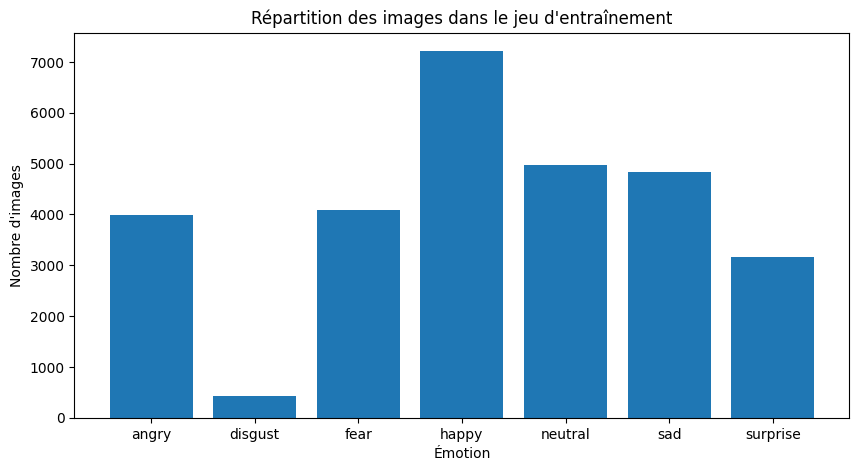

In [15]:


train_counts = []

for emotion in classes:
    path = os.path.join(train_dir, emotion)
    train_counts.append(len(os.listdir(path)))

plt.figure(figsize=(10, 5))

plt.bar(classes, train_counts)

plt.title("Répartition des images dans le jeu d'entraînement")
plt.xlabel("Émotion")
plt.ylabel("Nombre d'images")

plt.show()

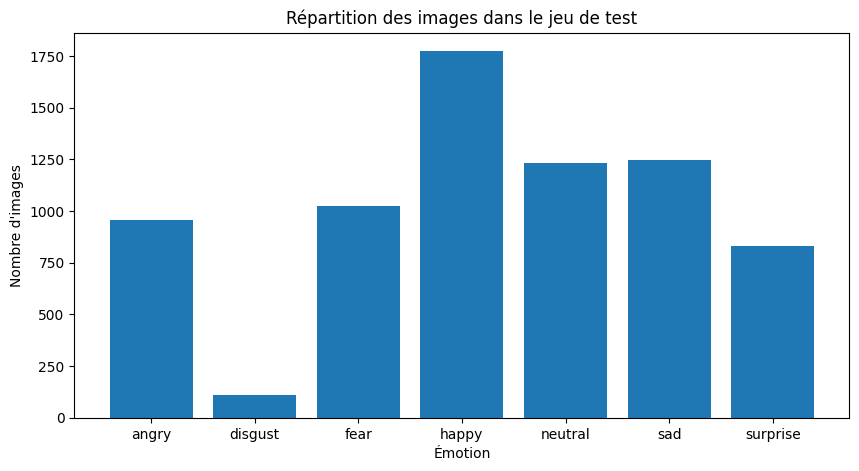

In [16]:
test_counts = []

for emotion in classes:
    path = os.path.join(test_dir, emotion)
    test_counts.append(len(os.listdir(path)))

plt.figure(figsize=(10, 5))

plt.bar(classes, test_counts)

plt.title("Répartition des images dans le jeu de test")
plt.xlabel("Émotion")
plt.ylabel("Nombre d'images")

plt.show()

In [17]:


# Prendre la première image de la première classe
emotion = classes[0]
image_name = os.listdir(os.path.join(train_dir, emotion))[0]

image_path = os.path.join(train_dir, emotion, image_name)

image = Image.open(image_path)

print("Nom :", image_name)
print("Format :", image.format)
print("Dimensions :", image.size)
print("Mode :", image.mode)

Nom : Training_28633118.jpg
Format : JPEG
Dimensions : (48, 48)
Mode : L


### Source du Dataset :  
lien : https://www.kaggle.com/datasets/aadityasinghal/facial-expression-dataset  
auteur : Aaditya Singhal  
license : https://opendatacommons.org/licenses/dbcl/1-0/

### Nombre totales d'images:  
28709 pour le train  
7159 pour le test

### Les différentes classes:  
Il y a 7 classes qui portent le nom de :  
* angry
* disgust
* fear
* happy
* neutral
* sad
* surprise

### Nombres d'images par classe:  
Le nombre d'image par classe est irrégulier, dans le cas des données d'entrainement on a :  
* angry : 3995
* disgust : 436
* fear : 4097
* happy : 7215
* neutral : 4965
* sad : 4830
* surprise : 3171

Il y a donc un déséquilibre entre les classes comme on peut le voir sur le graphique si dessus.


### Description des images :  
* Dimension : 48 * 48
* Format : image en niveau de gris / fichier jpeg

### Visualisation d'images pour chacune des classes:

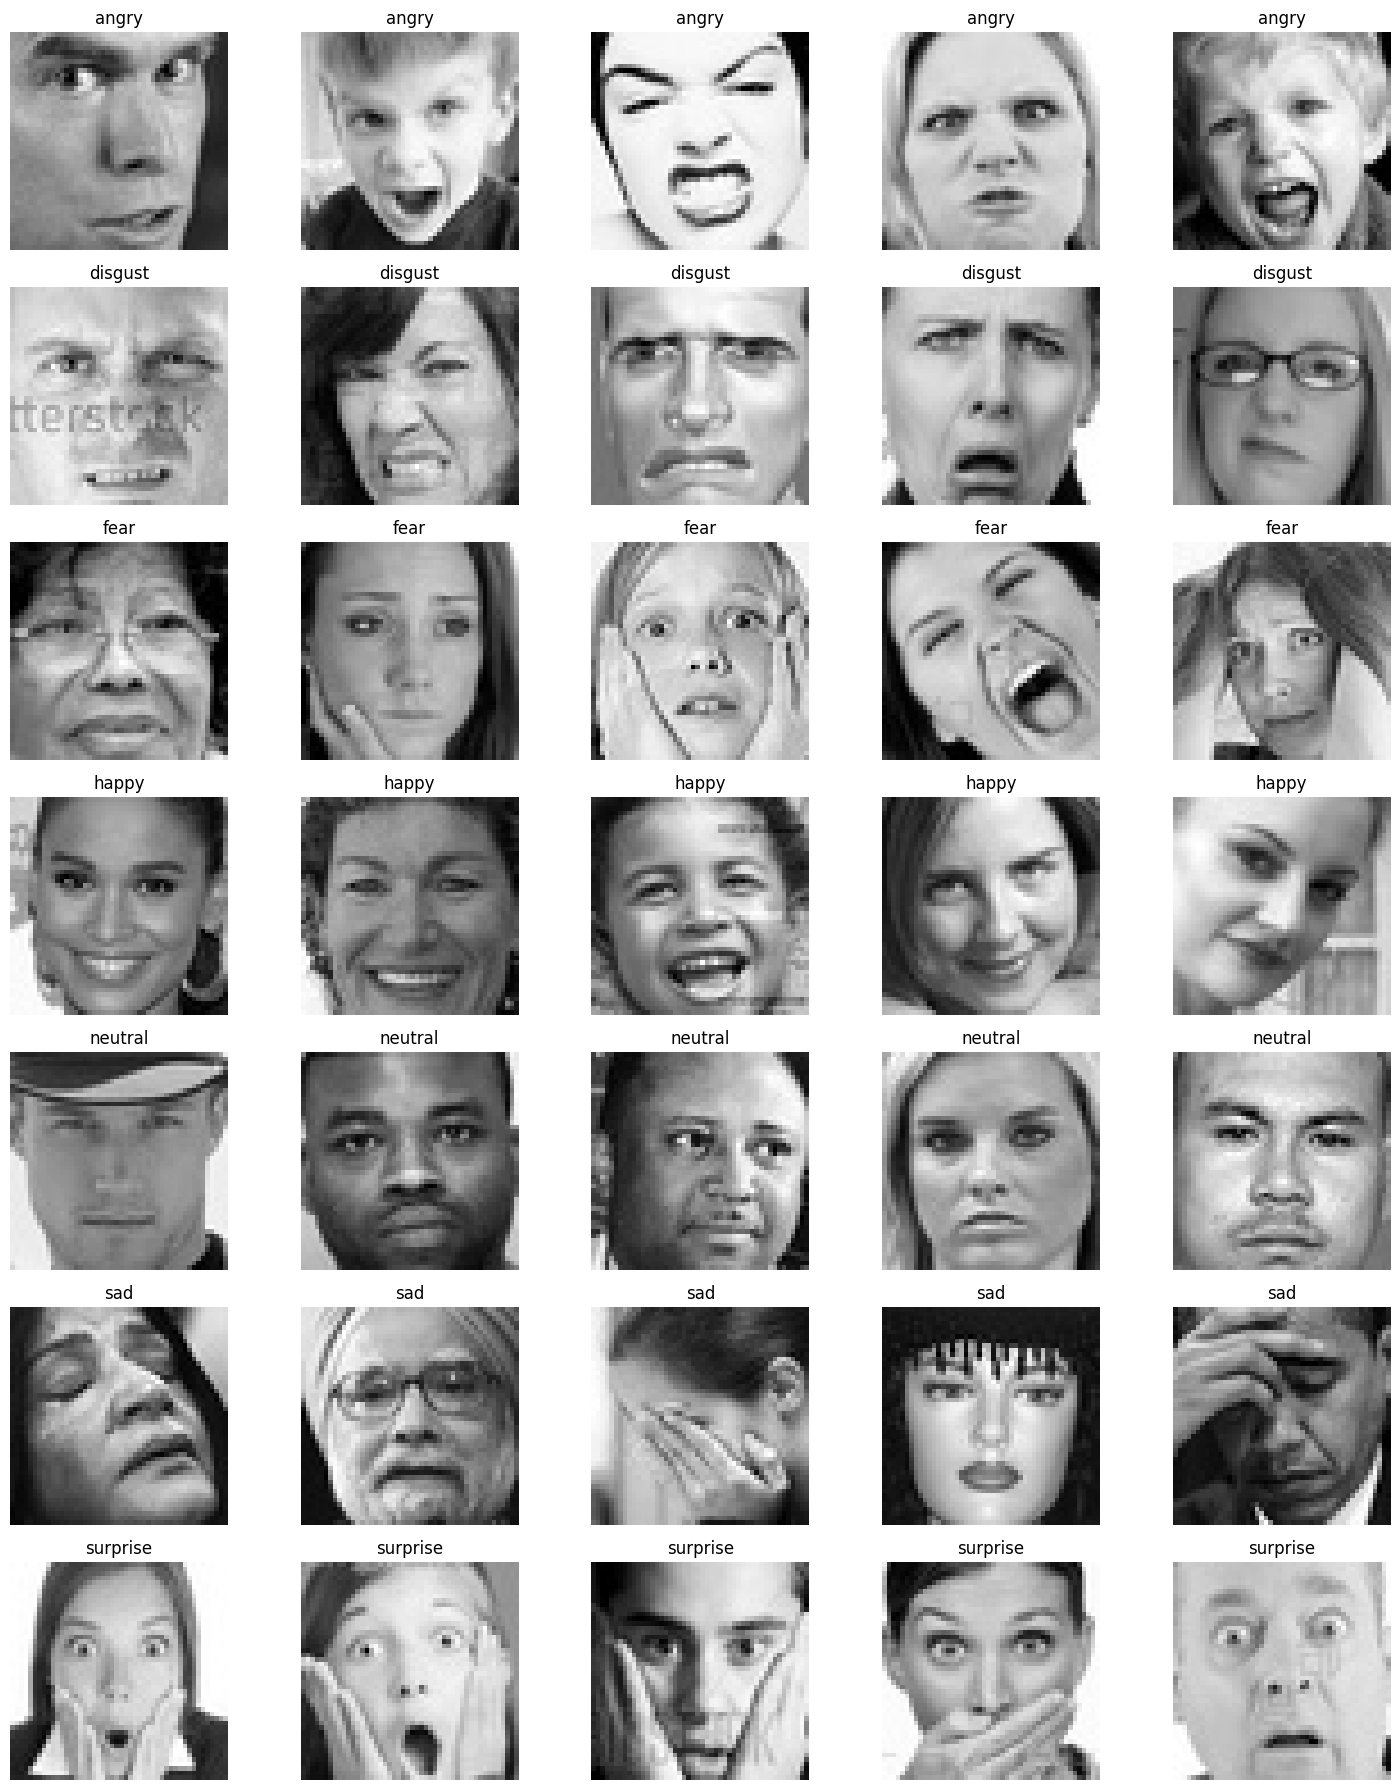

In [18]:
# Nombre d'images à afficher par classe
n_images = 5

plt.figure(figsize=(15, 18))

for row, emotion in enumerate(classes):

    emotion_dir = os.path.join(train_dir, emotion)
    image_names = os.listdir(emotion_dir)
    selected_images = random.sample(image_names, n_images)

    for col, image_name in enumerate(selected_images):

        image_path = os.path.join(emotion_dir, image_name)
        image = Image.open(image_path)

        position = row * n_images + col + 1

        ax = plt.subplot(len(classes), n_images, position)

        plt.imshow(image, cmap="gray")
        plt.title(emotion)
        plt.axis("off")

plt.tight_layout()
plt.show()

## Préparation des données

### Formatage des images

Cette partie permet de s'assurer que toutes les images est bien le même format et de faire des modification nécessaire par exemple réduire la taille des pixels si nécessaire pour eviter des calculs inutilement complexe.

In [19]:
# On vérifie que toutes les images soient bien en niveaux de gris
def check_image_modes(directory):
    modes = Counter()

    for root, dirs, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)

            try:
                with Image.open(path) as img:
                    modes[img.mode] += 1
            except:
                pass

    return modes


train_modes = check_image_modes(train_dir)
test_modes = check_image_modes(test_dir)

print("Modes dans TRAIN :", train_modes)
print("Modes dans TEST  :", test_modes)

Modes dans TRAIN : Counter({'L': 28709})
Modes dans TEST  : Counter({'L': 7178})


Toutes les images sont bien en niveaux de gris

In [20]:
# Idem que précedemment pour les dimensions
def check_image_sizes(directory):
    sizes = Counter()

    for root, dirs, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)

            try:
                with Image.open(path) as img:
                    sizes[img.size] += 1
            except:
                pass

    return sizes


train_sizes = check_image_sizes(train_dir)
test_sizes = check_image_sizes(test_dir)

print("Dimensions dans TRAIN :", train_sizes)
print("Dimensions dans TEST  :", test_sizes)

Dimensions dans TRAIN : Counter({(48, 48): 28709})
Dimensions dans TEST  : Counter({(48, 48): 7178})


Toutes les images sont de tailles 48 * 48 pixels qui est une taille acceptable (pas trop grosse), pas besoin de les redimmensionner.

In [21]:
def check_extensions(directory):
    extensions = Counter()

    for root, dirs, files in os.walk(directory):
        for file in files:
            extension = os.path.splitext(file)[1].lower()

            if extension:
                extensions[extension] += 1

    return extensions


print("Formats TRAIN :", check_extensions(train_dir))
print("Formats TEST  :", check_extensions(test_dir))

Formats TRAIN : Counter({'.jpg': 28709})
Formats TEST  : Counter({'.jpg': 7178})


Toutes les images sont bien au même format.

### Verification qu'aucune image du train ne se trouve dans le test

Cette partie permet d'éviter qu'on ne baiase accidentellement le modèle à cause de données de train qui se trouverai dans le test

In [22]:
def get_file_hash(path):
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            md5.update(chunk)

    return md5.hexdigest()

In [23]:
train_hashes = {}


for root, dirs, files in os.walk(train_dir):
    for file in files:

        path = os.path.join(root, file)

        try:
            file_hash = get_file_hash(path)
            train_hashes[file_hash] = path
        except:
            pass

print("Nombre d'images analysées dans TRAIN :", len(train_hashes))

Nombre d'images analysées dans TRAIN : 27473


Si le nombre d'images analyséess ne correspond pas au nombre totales d'images c'est dû à la presence de doublons dans les données de train on s'en occupera par la suite.

In [24]:
duplicates = []

for root, dirs, files in os.walk(test_dir):
    for file in files:

        path = os.path.join(root, file)

        try:
            file_hash = get_file_hash(path)

            if file_hash in train_hashes:
                duplicates.append(
                    (train_hashes[file_hash], path)
                )
        except:
            pass

In [25]:
print("Nombre de doublons TRAIN/TEST :", len(duplicates))

Nombre de doublons TRAIN/TEST : 568


On peut voir qu'il y a un certain nombre d'images présentent dans le train qui se trouvent également dans le test on va donc supprimer celles présentent dans le test

In [26]:
test_files_to_remove = set()

for train_paths, test_path in duplicates:
    test_files_to_remove.add(test_path)

print("Nombre d'images uniques du test à supprimer :", len(test_files_to_remove))

Nombre d'images uniques du test à supprimer : 568


In [27]:
for path in test_files_to_remove:
    os.remove(path)

print("Suppression terminée.")

print("Nombre d'images supprimées :", len(test_files_to_remove))

Suppression terminée.
Nombre d'images supprimées : 568


In [28]:
duplicates = []

for root, dirs, files in os.walk(test_dir):
    for file in files:

        path = os.path.join(root, file)

        try:
            file_hash = get_file_hash(path)

            if file_hash in train_hashes:
                duplicates.append(
                    (train_hashes[file_hash], path)
                )
        except:
            pass
print("Nombre de doublons TRAIN/TEST :", len(duplicates))

Nombre de doublons TRAIN/TEST : 0


Tous les images présentent à la fois dans le train et le test ont bien été supprimés du test

### Constitution des ensembles train / validation / test

Dans cette partie on construit les 3 ensembles qu'on va utilser pour le projet.

On a déja nos ensemble de train et de test, il ne reste plus qu'a prendre une partie des données du train pour créer l'ensemble de validation.  
On va découper le train en 80 % de train et 20 % de validation.

In [29]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [30]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 6610 files belonging to 7 classes.


### Vérification des ensembles

In [31]:
print("Classes TRAIN :", train_ds.class_names)
print("Classes VALIDATION :", val_ds.class_names)
print("Classes TEST :", test_ds.class_names)

Classes TRAIN : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Classes VALIDATION : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Classes TEST : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [32]:
for images, labels in train_ds.take(1):
    print("Shape des images :", images.shape)
    print("Shape des labels :", labels.shape)

Shape des images : (32, 48, 48, 1)
Shape des labels : (32,)


### Normalisation des pixels

Les pixels ont des valeurs comprises entre 0 et 255 pour éviter les risques d'overflow on va faire en sorte que leurs valeurs soient compris entre 0 et 1.

In [33]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

### Vérification des données

#### image avec son label

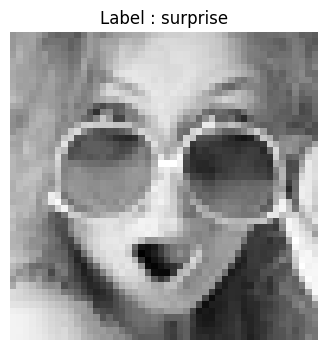

In [34]:
for images, labels in train_ds.take(1):
    image = images[0]
    label = labels[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(image.numpy().squeeze(), cmap="gray")
    plt.title(f"Label : {classes[label.numpy()]}")
    plt.axis("off")
    plt.show()

#### Taille des pixels

In [35]:
for images, labels in train_ds.take(1):

    min_pixel = tf.reduce_min(images).numpy()
    max_pixel = tf.reduce_max(images).numpy()

    print("Minimum :", min_pixel)
    print("Maximum :", max_pixel)

    if min_pixel >= 0 and max_pixel <= 1:
        print("✓ Tous les pixels sont bien dans [0, 1].")
    else:
        print("✗ Attention : certains pixels sont en dehors de [0, 1].")

Minimum : 0.0
Maximum : 1.0
✓ Tous les pixels sont bien dans [0, 1].


Ici nos labels étaient déjà prêts chacune des images à pour label le dossier auquel elle appartient.

# Partie 2 - Construction d'un modèle de référence

On va construire un modèle de référence qui servira à comparer avec le CNN construit dans la partie suivante. Ce modèle aura comme architecture la suivante : Image → Flatten → Dense + activation → Dense → Softmax.

Imports

In [36]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

On va travailler avec des images de taille 48*48 avec des niveaux de gris donc le canal choisi sera égal à 1. On veut que le résultat soit donné à travers les 7 classes d'émotions défini dans le dataset.

In [37]:
IMG_HEIGHT = 48
IMG_WIDTH = 48
CHANNELS = 1
NUM_CLASSES = len(classes)

baseline_model = Sequential([
    Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),

    Dense(128, activation="relu"),

    Dense(NUM_CLASSES, activation="softmax")
])

baseline_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,943 (1.13 MB)

 Trainable params: 295,943 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

Avec Flatten, notre matrice de taille 48*48 se transforme en un vecteur de taille 2304 avec chaque composante contenant la valeur en echelle de gris du pixel. Néanmoins, on a plus la notion d'espace puisque l'image est applati en un vecteur.

Compilation du modèle

In [38]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Entraînement du modèle

In [39]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.2764 - loss: 1.7888 - val_accuracy: 0.2777 - val_loss: 1.7647
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3238 - loss: 1.7090 - val_accuracy: 0.3431 - val_loss: 1.6823
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3376 - loss: 1.6850 - val_accuracy: 0.3353 - val_loss: 1.6864
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3446 - loss: 1.6722 - val_accuracy: 0.3374 - val_loss: 1.6866
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3501 - loss: 1.6593 - val_accuracy: 0.3553 - val_loss: 1.6554
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3537 - loss: 1.6548 - val_accuracy: 0.3377 - val_loss: 1.6703
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3587 - loss: 1.6421 - val_accuracy: 0.3616 - val_loss: 1.6429
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3565 - loss: 1.6413 - val_accuracy: 0

Visualisation de l'apprentissage du modèle

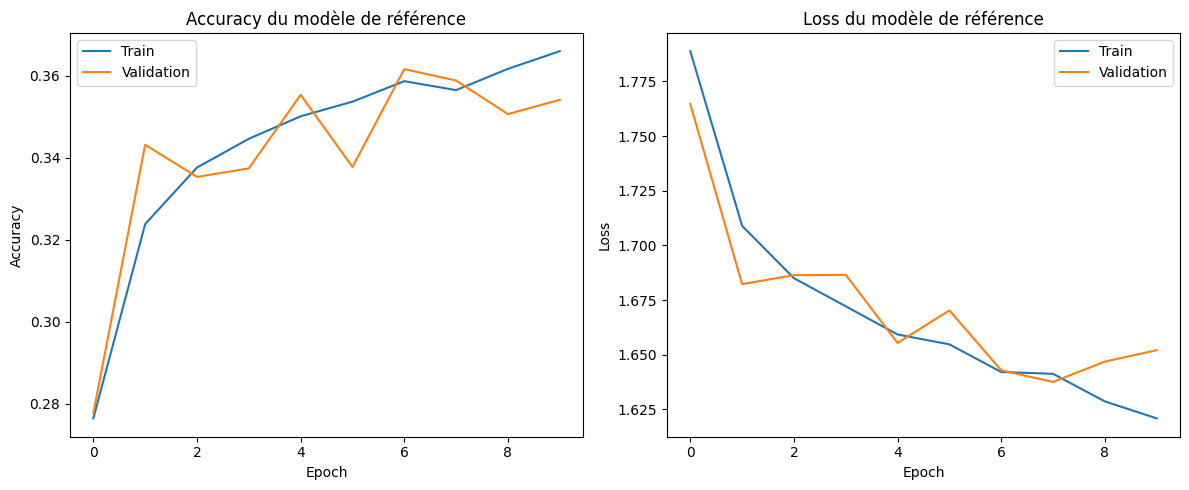

In [40]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history_baseline.history["accuracy"], label="Train")
plt.plot(history_baseline.history["val_accuracy"], label="Validation")

plt.title("Accuracy du modèle de référence")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(history_baseline.history["loss"], label="Train")
plt.plot(history_baseline.history["val_loss"], label="Validation")

plt.title("Loss du modèle de référence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Evaluation du modèle

In [41]:
test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print(f"Loss sur le test : {test_loss:.4f}")
print(f"Accuracy sur le test : {test_accuracy:.4f}")

207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3495 - loss: 1.6663
Loss sur le test : 1.6663
Accuracy sur le test : 0.3495


On obtiens une accuracy de 35% sur les données du modèle ce qui est insuffisant pour determiner correctement l'émotion d'une image. On voit que c'est un modèle pas adapté à ce genre d'usage car l'image n'est pas traité correctement

Sortie Softmax

In [42]:
for images, labels in test_ds.take(1):

    predictions = baseline_model.predict(images)

    image_index = 0

    print("Vrai label :", classes[labels[image_index].numpy()])
    print("\nProbabilités prédites :")

    for class_name, probability in zip(
        classes,
        predictions[image_index]
    ):
        print(f"{class_name:10s} : {probability:.4f}")

    predicted_class = np.argmax(predictions[image_index])

    print(
        "\nClasse prédite :",
        classes[predicted_class]
    )

    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Vrai label : angry

Probabilités prédites :
angry      : 0.2391
disgust    : 0.0244
fear       : 0.2720
happy      : 0.0244
neutral    : 0.0989
sad        : 0.1723
surprise   : 0.1688

Classe prédite : fear


Dans le cas d'une image, avec SoftMax, on va selectionner la classe avec la probabilité la plus élevée et ce résultat va donner l'émotion décrite pas l'image.

Question du cours :  

La fonction de perte permet de mesurer l'écart entre les classes prédites et les classes réelles du dataset. Lorsqu'elle est faible, le modèle fait moins d'erreurs et si elle est élevée, le modèle se trompe beaucoup.

La propagation vers l'avant permet à la donnée d'entrée, en l'occurance l'image dans notre cas, de traverser toutes les couches du système.

La rétropropagation permet de calculer les nouveaux biais et poids du réseau pour affiner les résultats du modèle.


# Partie 3 — Construction d’un CNN avec Keras

## Choix de l'architecture

$$
\begin{array}{c}
\text{Input : } 48 \times 48 \times 1 \\
\downarrow \\
\text{Conv2D}(32, 3 \times 3) + \text{ReLU}\\
\downarrow \\
\text{MaxPooling}(2 \times 2)\\  
\downarrow \\
\text{Conv2D}(64, 3 \times 3) + \text{ReLU}\\  
\downarrow \\
\text{MaxPooling}(2 \times 2)\\  
\downarrow \\
\text{Conv2D}(128, 3 \times 3) + \text{ReLU}\\  
\downarrow \\
\text{MaxPooling}(2 \times 2)\\
\downarrow \\
\text{Flatten}\\  
\downarrow \\
\text{Dense}(128) + \text{ReLU}\\  
\downarrow \\
\text{Dense}(7) + \text{Softmax}\\  
\end{array}
$$








Nous avons choisi cette architecture qui consiste à augmenter progressivement le nombre de filtes.  
L'idée est que les premières convolutions peuvent apprendre des caractéristiques relativement simples,  
puis les couches suivantes peuvent combiner ces caractéristiques pour construire des représentations plus complexes.

Tout en réduisant en parallèle progressivement la taille spatiale avec le pooling.

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [44]:
IMG_HEIGHT = 48
IMG_WIDTH = 48
CHANNELS = 1
NUM_CLASSES = len(classes)

cnn_model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dense(NUM_CLASSES, activation="softmax")
])


## Justification de l'architecture

1. Le rôle des filtres  
Les couches de convolution représente les couches qui contiennent les filtres par exemple notre première couche contient 32 filtres de taille 3 * 3.  
Un filtre est une petite matrice de nombres qui va parcourir l'image. Chaque filtre va progressivement apprendre à détecter certains motifs comme les contours, formes des yeux ...

Nous avons par exemple choisi s'utiliser 32 filtres pour la première couche de manière à ce que notre modèle puisse apprendre à reconnaitre suffisament de motifs simples, pour pouvoir reconnaitre par la suite des motifs plus complexes.

2. le principe de la convolution  
Prenons un filtre 3 * 3, le filtre va se poser sur un carré de dimension 3 * 3 de l'image. On va multiplier les valeurs du filtres avec celle de la partie de l'image puis faire la somme de ces valeurs, une fois cela fait on va décaller le filtre sur la droite et recommencer.

3. les feature maps  
Après avoir appliquer la convolution on obtiendra une matrice de valeur contenant une information spécifique, ces matrices sont appelées feature maps.  
Chaque feature map représente les endroits où le filtre correspondant a détecté quelque chose.


4. la taille du kernel  
La taille du kernel correspond à la taille de nos filtres.  

Nous choisissons 3×3 parce qu'il s'agit d'un kernel relativement petit permettant d'examiner localement l'image, sachant qu'on travaille avec des images de relativement petite taille (48 * 48), cela permet également de limter le nombre de parametres.

5. le stride   
Le stride indique de combien de pixels le filtre se déplace à chaque étape.

Nous avons choisi de conseverver le stride initial qui est de 1 pour garder toute l'information, on pourrait décider d'augmenter le stride pour réduire les dimensions spatiales si la perte d'information est acceptable.

6. le padding  
Le padding correspond à l'ajout éventuel de pixels autour de l'image avant la convolution, de manière à conserver la même taille spatiale (taille de l'image) en sortant de la couche de convolution.

Dans notre cas nous avons décidé de ne pas ajouter de padding si ce n'est pas nécessaire.

7. ReLU
ReLU(x) = max(0, x)  
Utiliser ReLU permet d'introduire une non-linéarité dans le réseau. Sans cette non-linéarité, empiler plusieurs couches linéaires ne permettrait pas au réseau d'apprendre des relations suffisamment complexes.

8. le pooling
Le pooling regarde des petites régions 2×2 (dans notre cas) et conserve uniquement la valeur maximale.  
Avec un pooling 2×2 et un stride de 2, on passe de feature maps de taille 46 * 46 à 23 * 23.  
Faire du pooling permet de réduire la taille des données et par extension réduire le nombre de calculs ainsi que rendre les représentations moins sensibles à de petits déplacements, cependant il entraîne une perte d'information.

9. Flatten  
L'applatissage (ou Flatten) permet de transformer un tenseur en vecteur de manière a pouvoir faire la classification.

10. les couches Dense
Leurs rôles est de combiner les caractéristiques extraites par les convolutions afin de prendre une décision de classification.

11. La couche de sortie
La couche de sortie correspond finalement à un vecteur qui va associé chaque classe a une probabilité.

Notre architecture est donc composé de 3 phases:
* la première phase, l'extraction des caractéristiques qui regroupent les couches de convolution et de pooling.
* la seconde phase, la transformation des caractéristique avec le flatten.
* la dernière phase, la classification avec les couches denses et le softmax.

## Evolution des dimensions des données et du nombre de paramètres couche par couche

In [45]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### évolutions des dimesions:  
* Initiallement les dimensions d'une image sont de (48,48,1)
* avec la première couche conv2D on créé 32 filtres de taille (3,3) ce qui fait qu'on obtient un tenseur de dimension((48 - 3) /1 + 1, (48 - 3) /1 + 1, 32) = (46,46,32)
* avec le pooling les dimensions de chaque filtre vont être divisé par 2 ce qui fait qu'on obtientun tenseur de dimension (23,23,32)
* seconde couche conv2D même principe mais avec 64 filtres : ((23 - 3) /1 + 1, (23 - 3) /1 + 1, 32) = (21,21,64)
* second pooling on redivise les dimension des filtres, d'où (10,10,64)
* troisième couche conv2D même principe mais avec 128 filtres : (8,8,128)
* troisième pooling on obtient (4,4,128)
* avec le flatten on va applentir le tenseur autrement dit on va mettre toutes les valeurs à la suite donc les dimensions font: (4*4*128) = 2048
* première couche dense les 2048 entrées se connectent avec 128 neurrones donc on obtient un vecteur de 128 valeurs
* deuxième couche dense avec le softmax, ces 128 valeurs vont se transformer en 7 probabilité chacune associé à une classe

### évolution du nombre de paramètre:
* on part de 48 * 48 * 1, on applique Conv2D(32, (3,3)) chaque filtre posède 3 * 3 * 1 = 9 poids auquel on ajoute 1 biais ce qui donne 10 paramètre multiplié par le nombre de filtre : 10 * 32 = 320 paramètres
* le pooling n'a aucun poids à apprendre
* deuxième couche de convolution, chaque filtre à 3 * 3 * 32 biais + 1 poids = 289 paramètres * le nombre de filtre = 64 -> 289 * 64 =  18 496 paramètres
* pooling pas de paramètre
*  troisième couche de convolution, chaque filtre à 3 * 3 * 64 biais + 1 poids = 577 paramètres * le nombre de filtre = 128 -> 577 * 128 =  73 856 paramètres
* pooling pas de paramètre
* flatten pas de paramètres
* Dense (128), on a 2048 valeur chacun des 128 neurone vas recevoir ces 2048 valeurs et va leur associé un poids -> 2048 poids + 1 biais et ce la pour les 128 neuronnes ce qui donne 2049 * 128 = 262 272 paramètres
* Dense (7), On a 128 valeurs et 7 neurones chaque neurone associe un poids à chacune des 128 valeures et leur ajoutes un biais ce qui donne 7 * (128 + 1) = 903 paramètres.

# Partie 4 - Entraînement du réseau

Pour cette partie, on va entrainer le modèle CNN construit dans la partie précédente.

Compilation du réseau CNN

In [46]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

On a choisi l'optimiseur Adam car il est assez pratique pour mettre à jour les poids du réseau à chaque pas d'entrainement.

Pour les metrics, l'accuracy va décider de la performance du modèle et suivre la proportion d'image proprement bien classés.

Enfin, la loss est calculé avec le categorical cross entropy puisqu'on travaille avec 7 classes en sortie et des labels qui sont entiers.

On se propose pour l'entrainement de travailler sur 20 epochs et des batchs de taille 32.

Entraînement du modèle

In [47]:
EPOCHS = 20

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.3575 - loss: 1.6351 - val_accuracy: 0.4414 - val_loss: 1.4683
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4682 - loss: 1.3928 - val_accuracy: 0.4881 - val_loss: 1.3450
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5138 - loss: 1.2751 - val_accuracy: 0.5086 - val_loss: 1.2879
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5518 - loss: 1.1865 - val_accuracy: 0.5226 - val_loss: 1.2562
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5834 - loss: 1.1102 - val_accuracy: 0.5372 - val_loss: 1.2222
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6097 - loss: 1.0408 - val_accuracy: 0.5351 - val_loss: 1.2235
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6382 - loss: 0.9690 - val_accuracy: 0.5313 - val_loss: 1.2640
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6642 - loss: 0.9045 - val_accuracy: 

On va travailler sur des bacths de taille 32 préalablement défini dans la préparation des données et sur 20 epochs, que l'on ajustera selon les besoins du modèle. Un epoch est un passage complet du modèle sur les données d'entrainement. Avec 20 passages, on peut assurer déjà un bon entrainement du modèle sur les données.

Visualisation de l'accuracy

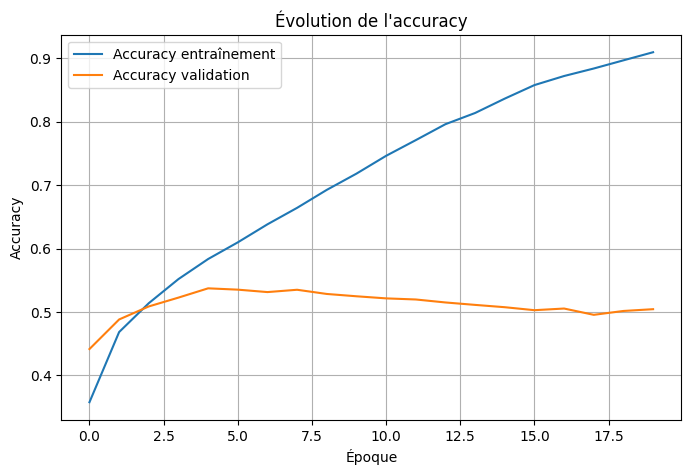

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history["accuracy"],
    label="Accuracy entraînement"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Accuracy validation"
)

plt.title("Évolution de l'accuracy")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

Visualisation de la loss

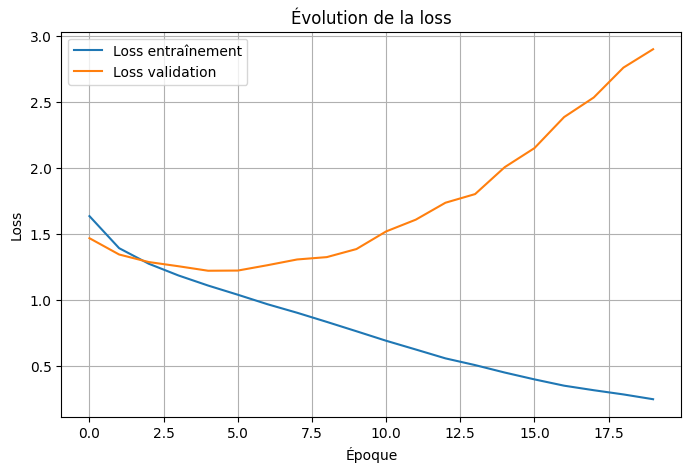

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history["loss"],
    label="Loss entraînement"
)

plt.plot(
    history_cnn.history["val_loss"],
    label="Loss validation"
)

plt.title("Évolution de la loss")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

Interprétation

On s'aperçoit qu'on a une accuracy de 91% sur le set d'entrainement mais une accuracy de 49% soit une différence de 42 points entre les deux sets ce qui est un symbole d'un surapprentissage.

Même constat avec la loss qui est de 0.25 et 2.8 pour les sets d'entrainement et de validation respectivement. Néanmoins, on peut voir que le modèle atteint ses meilleurs performances à l'epoch 5 de l'entrainement avec une loss de 1.23 et une accuracy de 53%.

Notre modèle apprend de plus en plus précisèment les données, perd en efficacité visiblement  à partir de l'epoch 5 et généralise de moins en moins bien sur des données qu'il n'a pas visualisés.

# Partie 5 — Évaluation et analyse des erreurs

## Matrice de confusion

In [50]:
y_true = []
y_pred = []
y_proba = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
    y_proba.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

print("Nombre d'images test :", len(y_true))
print("Shape y_true :", y_true.shape)
print("Shape y_pred :", y_pred.shape)
print("Shape y_proba :", y_proba.shape)

Nombre d'images test : 6610
Shape y_true : (6610,)
Shape y_pred : (6610,)
Shape y_proba : (6610, 7)


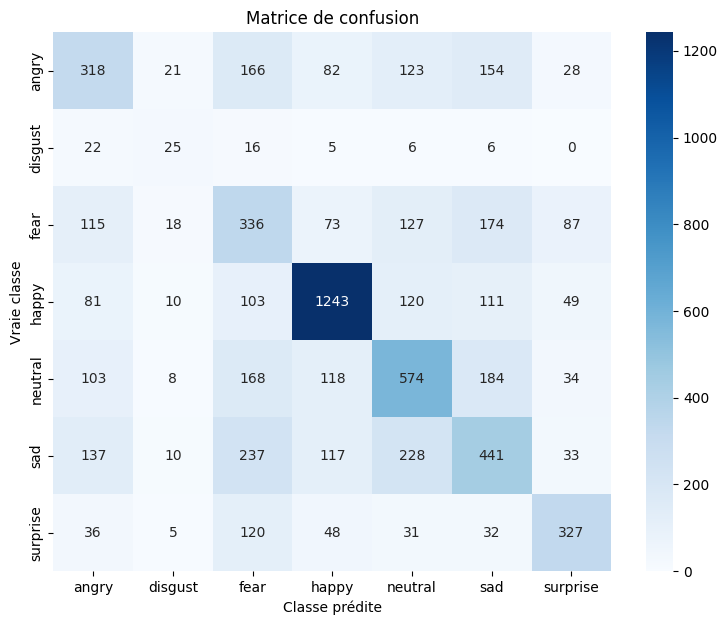

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Classe prédite")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion")
plt.show()

On peut observer sur cette matrice de confusion que certaines classes sont généralement bien reconnu comme les classes happy, neutral et surprise.  
Tandis que pour d'autre classe comme angry, fear et sad elles sont souvent mal prédites.  
La classe angry est assez régulierment prédite comme etant neutral ou sad.  
De même pour la classe fear.
La classe sad est presque la moitié du temps prédite comme étant la classe neutral et également assez souvent confondus avec les autres classes.   
On peut ajouter un dernier point c'est que le modèle prédit beaucoup plus souvent neutral que le nombre de fois réelle où elle apparaît.

## Statistiques pour toutes les classes

In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

       angry       0.39      0.36      0.37       892
     disgust       0.26      0.31      0.28        80
        fear       0.29      0.36      0.32       930
       happy       0.74      0.72      0.73      1717
     neutral       0.47      0.48      0.48      1189
         sad       0.40      0.37      0.38      1203
    surprise       0.59      0.55      0.57       599

    accuracy                           0.49      6610
   macro avg       0.45      0.45      0.45      6610
weighted avg       0.50      0.49      0.50      6610



In [53]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

,precision,recall,f1-score,support
angry,0.391626,0.356502,0.373239,892.000000
disgust,0.257732,0.312500,0.282486,80.000000
fear,0.293194,0.361290,0.323699,930.000000
happy,0.737248,0.723937,0.730532,1717.000000
neutral,0.474773,0.482759,0.478732,1189.000000
sad,0.400181,0.366584,0.382646,1203.000000
surprise,0.586022,0.545910,0.565255,599.000000
accuracy,0.493797,0.493797,0.493797,0.493797
macro avg,0.448682,0.449926,0.448084,6610.000000
weighted avg,0.500064,0.493797,0.496069,6610.000000


Comme vu précedemment les classes qui possèdent les meilleurs score sont "happy" et "surprise" suivi de "neutral".  
Celle ayant les plus faibles performances sont disgust (dû au trop faible nombres d'images présentes dans le train et dans le test), suivi de fear, sad et angry.  

On peut supposer que le modèle a plus difficulté à prédire les classes dont les images possèdent des caractéristiques proches (comme la taille des yeux).  
Et que au contraire elle prédit plus facilement les classes dont les images ont des caractéristiques très différentes des autres.

Pour rappel:
* la précision désigne le nombre d'images correctement prédites (parmis les images prédites combient appartient réellement à leur classe)
* le recall désigne le nombre d'image appartenant à une classe qui ont été correctement prédite (par exemple combien d'image de "happy" ont été prédite comme "happy")
* le f1 score fait une moyenne harmonique de la précision et du recall :  
f1 = 2 * (precision * recall) / (precision + recall)

## Exemples d'images

In [54]:
test_images = []
test_labels = []

for images, labels in test_ds:
    test_images.extend(images.numpy())
    test_labels.extend(labels.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)

print(test_images.shape)
print(test_labels.shape)

(6610, 48, 48, 1)
(6610,)


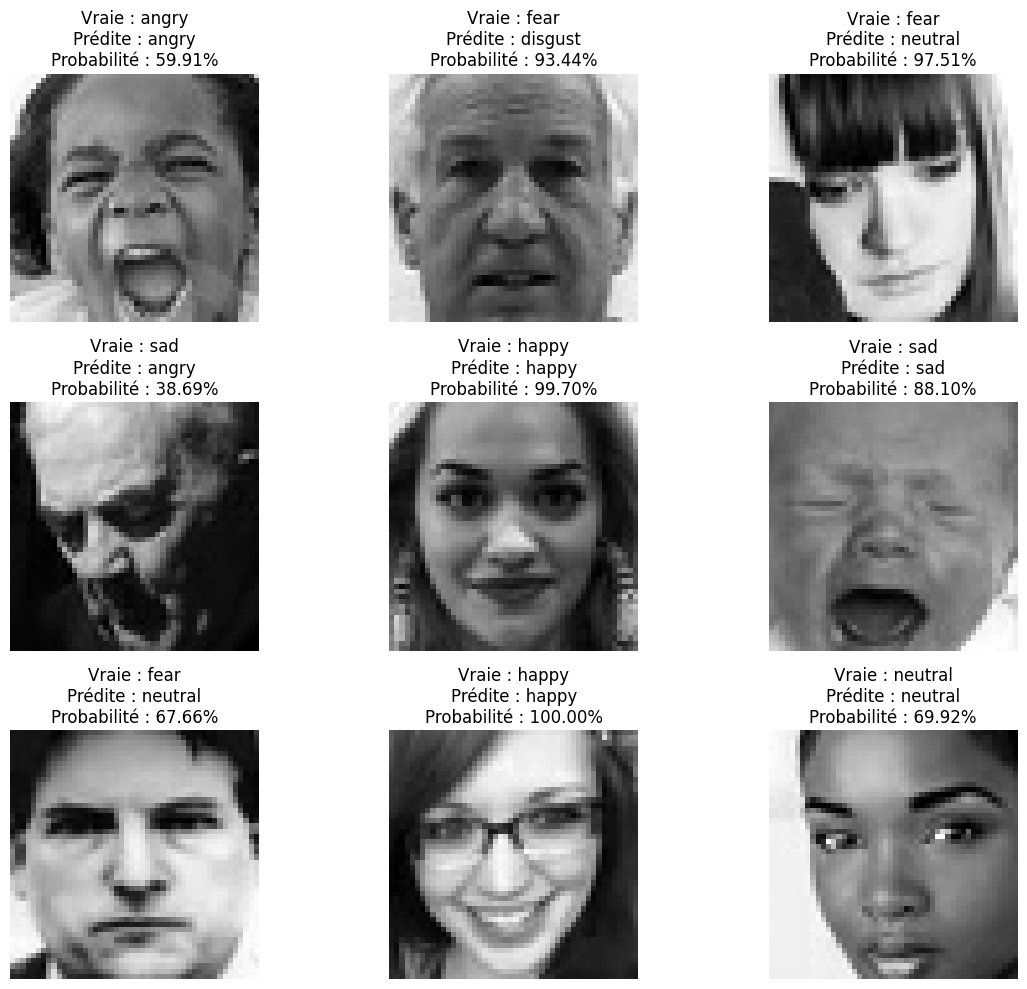

In [55]:
np.random.seed(164)
indices = np.random.choice(
    len(test_images),
    size=9,
    replace=False,
)

plt.figure(figsize=(12, 10))

for i, idx in enumerate(indices):
    image = test_images[idx]
    true_label = test_labels[idx]

    probabilities = cnn_model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )[0]

    predicted_label = np.argmax(probabilities)
    confidence = probabilities[predicted_label]

    plt.subplot(3, 3, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.axis("off")

    plt.title(
        f"Vraie : {classes[true_label]}\n"
        f"Prédite : {classes[predicted_label]}\n"
        f"Probabilité : {confidence:.2%}"
    )

plt.tight_layout()
plt.show()

On peut voir que le modèle c'est trompé sur 7 images parmis les 9 séléctionné aléatoirement.  
Bien que cela ne soit pas représentatif pour tout le jeu de test cela montre tout de même les faibles performances du modèle.

Parfois il se trompe même alors qu'il est très sûr de lui, comme pour les images 4 et 8 où il se trompe malgré des probabiltés de 93 et 94 %.  
Dans ces 2 cas un humain ne se serait pas probablement pas trompé.  
Ces 2 images se ressemblant beaucoup on peut supposer que le modèle aurait appris à reconnaitre de mauvaises caractéristiques.

Cependant on peut également observé que pour d'autres images, le modèle se trompe mais même un humain pourrait se tromper.  
Comme pour les images 3 et 9. où les vrais classes ne sont pas évidente à deviner.

# Partie 6 - Experimentation et amélioration

Notre CNN actuelle a un problème de reconnaissance pour certaines classes d'émotions dù à une faible accuracy. On va essayer d'améliorer son accuracy (qui est de 49% actuellement) en proposant des modifications de l'architecture actuelle.

On va notamment ajouter des éléments qui vont limiter le surapprentissage qui intervient très tôt durant notre entrainement et améliorer la généralisation de l'apprentissage pour que le modèle reconnaisse plus correctement les images fournies.

Résultats du CNN sans modification

In [56]:
baseline_val_accuracy = max(history_cnn.history["val_accuracy"])
baseline_val_loss = min(history_cnn.history["val_loss"])

print(f"Meilleure accuracy de validation : {baseline_val_accuracy:.4f}")
print(f"Meilleure loss de validation : {baseline_val_loss:.4f}")


Meilleure accuracy de validation : 0.5372
Meilleure loss de validation : 1.2222


In [57]:
results = []

results.append({
    "Expérience": "Modèle de référence",
    "Modification": "Aucune",
    "Val Accuracy": baseline_val_accuracy,
    "Val Loss": baseline_val_loss
})

results

[{'Expérience': 'Modèle de référence',
  'Modification': 'Aucune',
  'Val Accuracy': 0.5371886491775513,
  'Val Loss': 1.222170114517212}]

1er Test : Ajout d'une couche DropOut

La couche DropOut a pour fonction de désactiver une proportion de neurones dans le réseau ce qui va limiter le surapprentissage de notre modèle et aider le modèle à mieux généraliser. On va l'ajouter juste après la couche Dense (128) et on va désactiver la moitié des neurones du réseau. On va faire un entrainement de la même manière que pour le CNN et on comparera les résultats pour constater une évolution.

In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

dropout_model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dropout_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Entrainement

In [83]:
history_dropout = dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.2897 - loss: 1.7526 - val_accuracy: 0.3823 - val_loss: 1.5740
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3977 - loss: 1.5500 - val_accuracy: 0.4457 - val_loss: 1.4686
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4423 - loss: 1.4391 - val_accuracy: 0.4654 - val_loss: 1.3821
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4778 - loss: 1.3643 - val_accuracy: 0.4862 - val_loss: 1.3469
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5007 - loss: 1.3065 - val_accuracy: 0.5020 - val_loss: 1.2967
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5209 - loss: 1.2555 - val_accuracy: 0.5154 - val_loss: 1.2589
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5384 - loss: 1.2106 - val_accuracy: 0.5241 - val_loss: 1.2474
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5550 - loss: 1.1586 - val_accuracy: 

Résultats

In [60]:
dropout_val_accuracy = max(history_dropout.history["val_accuracy"])
dropout_val_loss = min(history_dropout.history["val_loss"])

print(f"Meilleure accuracy validation : {dropout_val_accuracy:.4f}")
print(f"Meilleure loss validation : {dropout_val_loss:.4f}")

Meilleure accuracy validation : 0.5544
Meilleure loss validation : 1.2038


Courbes

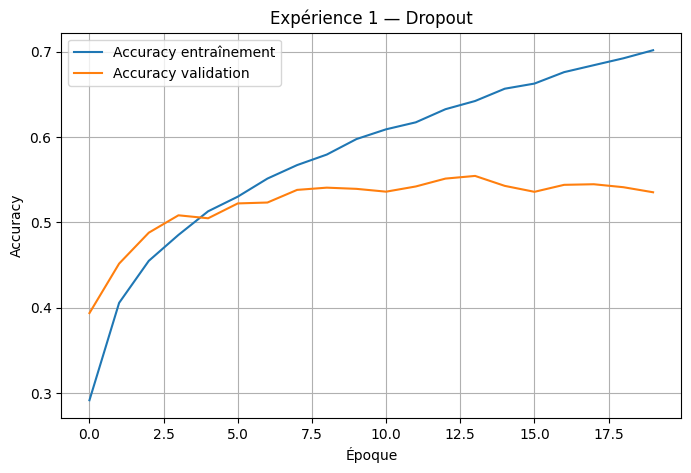

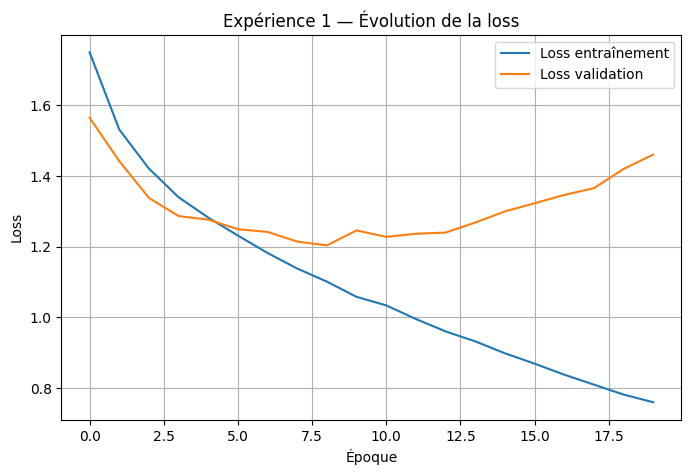

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_dropout.history["accuracy"],
    label="Accuracy entraînement"
)

plt.plot(
    history_dropout.history["val_accuracy"],
    label="Accuracy validation"
)

plt.title("Expérience 1 — Dropout")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    history_dropout.history["loss"],
    label="Loss entraînement"
)

plt.plot(
    history_dropout.history["val_loss"],
    label="Loss validation"
)

plt.title("Expérience 1 — Évolution de la loss")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

Comparaison CNN model /DropOut model

In [62]:
results.append({
    "Expérience": "Expérience 1",
    "Modification": "Dropout 0.5",
    "Val Accuracy": dropout_val_accuracy,
    "Val Loss": dropout_val_loss
})

2ème Test : Data Augmentation + Couche DropOut

Pour ce test, on va faire de la Data Augmentation, c'est à dire le fait de faire des rotations aux images, des zooms, de les déplacer, de les inverser dans le but de gonfler le jeu de données. On garde la couche DropOut dans le modèle du CNN et on comparera le résultat au CNN et au DropOutmodel précedent du test 1.

Data Augmentation

In [63]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05)
])

Construction du modèle

In [64]:
augmentation_model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),

    data_augmentation,

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

augmentation_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

augmentation_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Entrainement

In [65]:
history_augmentation = augmentation_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.2630 - loss: 1.7866 - val_accuracy: 0.3135 - val_loss: 1.6887
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3219 - loss: 1.6949 - val_accuracy: 0.3853 - val_loss: 1.5747
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3597 - loss: 1.6220 - val_accuracy: 0.4149 - val_loss: 1.5187
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3893 - loss: 1.5694 - val_accuracy: 0.4396 - val_loss: 1.4731
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4124 - loss: 1.5206 - val_accuracy: 0.4644 - val_loss: 1.4091
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4259 - loss: 1.4868 - val_accuracy: 0.4717 - val_loss: 1.3772
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4399 - loss: 1.4592 - val_accuracy: 0.4868 - val_loss: 1.3391
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4491 - loss: 1.4332 - val_a

Résultats

In [66]:
augmentation_val_accuracy = max(
    history_augmentation.history["val_accuracy"]
)

augmentation_val_loss = min(
    history_augmentation.history["val_loss"]
)

print(f"Meilleure accuracy validation : {augmentation_val_accuracy:.4f}")
print(f"Meilleure loss validation : {augmentation_val_loss:.4f}")

Meilleure accuracy validation : 0.5285
Meilleure loss validation : 1.2262


Courbes

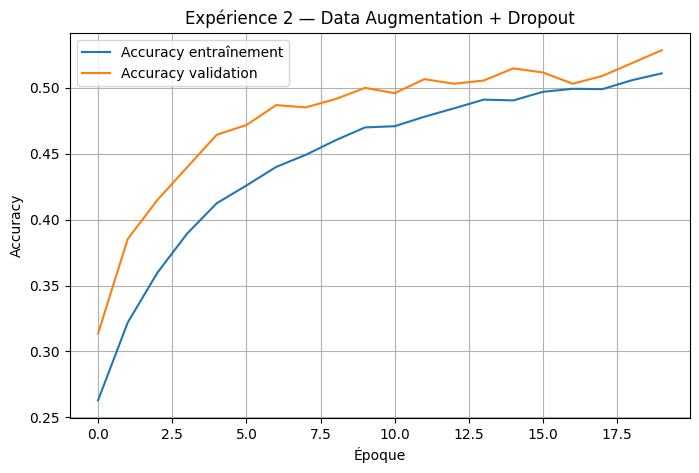

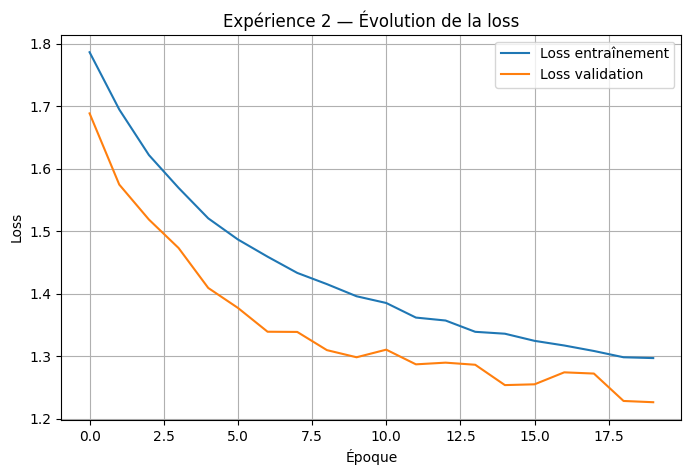

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_augmentation.history["accuracy"],
    label="Accuracy entraînement"
)

plt.plot(
    history_augmentation.history["val_accuracy"],
    label="Accuracy validation"
)

plt.title("Expérience 2 — Data Augmentation + Dropout")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history_augmentation.history["loss"],
    label="Loss entraînement"
)

plt.plot(
    history_augmentation.history["val_loss"],
    label="Loss validation"
)

plt.title("Expérience 2 — Évolution de la loss")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

Comparaison CNN et Data Augmentaion + DropOut

In [67]:
results.append({
    "Expérience": "Expérience 2",
    "Modification": "Data Augmentation + Dropout",
    "Val Accuracy": augmentation_val_accuracy,
    "Val Loss": augmentation_val_loss
})

3ème Test : Early Stopping et réduction du learning rate

Puisque notre modèle de départ atteignait son pic au bout du 5ème epochs sur 20, on va travailler sur du Early Stopping. Le principe de cette méthode est de stopper l'entrainement quand la loss commence à monter, c'est à dire lorsque le modèle comment à faire de mauvaises prédictions.

In [70]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

Construction du modèle

In [71]:
final_experiment_model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),

    data_augmentation,

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

final_experiment_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Entrainement

In [72]:
history_final = final_experiment_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.2646 - loss: 1.7905 - val_accuracy: 0.3390 - val_loss: 1.6750 - learning_rate: 0.0010
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3255 - loss: 1.6844 - val_accuracy: 0.4085 - val_loss: 1.5400 - learning_rate: 0.0010
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3735 - loss: 1.6039 - val_accuracy: 0.4409 - val_loss: 1.4510 - learning_rate: 0.0010
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4091 - loss: 1.5344 - val_accuracy: 0.4503 - val_loss: 1.4188 - learning_rate: 0.0010
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4265 - loss: 1.4849 - val_accuracy: 0.4790 - val_loss: 1.3411 - learning_rate: 0.0010
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4448 - loss: 1.4469 - val_accuracy: 0.4917 - val_loss: 1.3265 - learning_rate: 0.0010
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4551 - loss: 1

Résultats

In [73]:
final_val_accuracy = max(
    history_final.history["val_accuracy"]
)

final_val_loss = min(
    history_final.history["val_loss"]
)

print(f"Meilleure accuracy validation : {final_val_accuracy:.4f}")
print(f"Meilleure loss validation : {final_val_loss:.4f}")

print(
    f"Nombre réel d'époques effectuées : "
    f"{len(history_final.history['loss'])}"
)

Meilleure accuracy validation : 0.5536
Meilleure loss validation : 1.1670
Nombre réel d'époques effectuées : 30


Courbes

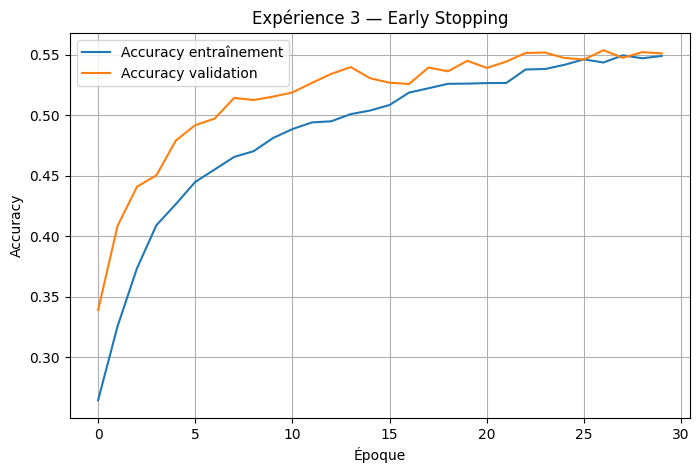

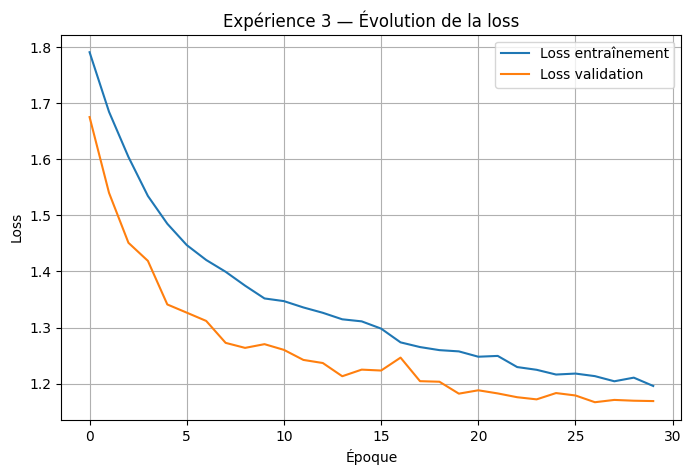

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_final.history["accuracy"],
    label="Accuracy entraînement"
)

plt.plot(
    history_final.history["val_accuracy"],
    label="Accuracy validation"
)

plt.title("Expérience 3 — Early Stopping")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history_final.history["loss"],
    label="Loss entraînement"
)

plt.plot(
    history_final.history["val_loss"],
    label="Loss validation"
)

plt.title("Expérience 3 — Évolution de la loss")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

In [78]:
results.append({
    "Expérience": "Expérience 3",
    "Modification": "Data Augmentation + Dropout + Early Stopping + ReduceLROnPlateau",
    "Val Accuracy": final_val_accuracy,
    "Val Loss": final_val_loss
})

Comparaison entre les tests et le modèle de base

In [79]:
results_df = pd.DataFrame(results)

results_df

,Expérience,Modification,Val Accuracy,Val Loss
0,Modèle de référence,Aucune,0.537189,1.222170
1,Expérience 1,Dropout 0.5,0.554433,1.203822
2,Expérience 2,Data Augmentation + Dropout,0.528479,1.226184
3,Expérience 3,Data Augmentation + Dropout + Early Stopping +...,0.553562,1.166965


Conclusion des modèles

Les trois expériences montrent que les différentes techniques testées n'ont pas toutes le même effet sur notre modèle.

L'ajout du Dropout permet d'améliorer l'accuracy de validation par rapport au modèle de référence et atteint une meilleure accuracy de 55,44 %. La Data Augmentation combinée au Dropout donne quant à elle une accuracy plus faible de 52,85 %, ce qui montre que les transformations utilisées ne permettent pas, dans notre cas, d'améliorer directement les performances.

Enfin, la troisième expérience, combinant Data Augmentation, Dropout, Early Stopping et réduction progressive du learning rate, atteint une accuracy de validation de 55,36 % et une loss de validation de 1,1670, qui est la plus faible des expériences réalisées.

Les performances en accuracy des expériences 1 et 3 sont très proches. Nous retenons donc le modèle de la troisième expérience comme modèle final expérimental, car il présente la loss de validation la plus faible et bénéficie d'une stratégie d'apprentissage adaptative grâce à la réduction progressive du learning rate.

Ces expériences montrent également que les techniques de régularisation et d'optimisation permettent de réduire les effets du surapprentissage, mais que les performances restent limitées. Les difficultés observées dans la partie précédente pour certaines expressions, notamment les classes minoritaires, peuvent notamment limiter les performances globales du modèle.